# Text Classification with Naive Bayes
### CS 412 — Machine Learning | Recitation 10

**Author:** Sima Adleyba  
**Email:** adleyba@sabanciuniv.edu  
**Date:** May 2026

## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interact
import re, math, string
%matplotlib inline

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0a0e1a'
plt.rcParams['axes.facecolor']   = '#0a0e1a'
plt.rcParams['axes.edgecolor']   = '#2d3748'
plt.rcParams['axes.labelcolor']  = '#e2e8f0'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['xtick.color']      = '#a0aec0'
plt.rcParams['ytick.color']      = '#a0aec0'
plt.rcParams['figure.dpi']       = 100

BLUE   = '#60a5fa'
RED    = '#f87171'
GREEN  = '#4ade80'
AMBER  = '#fbbf24'
VIOLET = '#a78bfa'
GRAY   = '#6b7280'

print('Setup complete.')

Setup complete.


## 1. From Text to Vectors

Every classifier expects a fixed-length numeric input. Text does not come that way.
The first task is always: turn a variable-length string into a fixed-length vector.

The full pipeline:

$$\text{raw text} \xrightarrow{\text{preprocess}} \text{tokens} \xrightarrow{\text{vocabulary}} \mathbf{x} \in \mathbb{R}^{|V|} \xrightarrow{\text{NB}} P(y \mid \mathbf{x})$$

We choose a **vocabulary** $V = \{w_1, w_2, \ldots, w_{|V|}\}$, then represent each document as a vector of length $|V|$. How we fill that vector is what distinguishes Bernoulli from Multinomial NB.

In [ ]:
# ── A small toy corpus (movie micro-reviews) ──
corpus = [
    ("great film loved every moment",      "pos"),
    ("brilliant acting wonderful story brilliant",   "pos"),
    ("loved characters great ending",      "pos"),
    ("great story wonderful great acting",       "pos"),
    ("loved every moment brilliant film",  "pos"),
    ("terrible film boring slow moment",   "neg"),
    ("awful acting hated every moment",    "neg"),
    ("worst film ever slow worst boring",        "neg"),
    ("boring story terrible terrible acting",       "neg"),
    ("hated every moment awful film",      "neg"),
]

docs   = [d for d, _ in corpus]
labels = [l for _, l in corpus]

# Build vocabulary (sorted for reproducibility)
all_words = sorted(set(w for doc in docs for w in doc.split()))
vocab     = {w: i for i, w in enumerate(all_words)}
V         = len(vocab)

print(f"Vocabulary ({V} words):", list(vocab.keys()))

Vocabulary (18 words): ['acting', 'awful', 'boring', 'brilliant', 'characters', 'ending', 'ever', 'every', 'film', 'great', 'hated', 'loved', 'moment', 'slow', 'story', 'terrible', 'wonderful', 'worst']


### 1.1 Bernoulli Encoding

Each feature $x_t \in \{0, 1\}$ records only **presence or absence** of word $w_t$.
Repetition is ignored: "great great great" gives the same vector as "great".

$$x_t = \mathbf{1}[w_t \in d]$$

In [ ]:
def bernoulli_encode(doc, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    for w in doc.split():
        if w in vocab:
            vec[vocab[w]] = 1
    return vec

X_bern = np.array([bernoulli_encode(d, vocab) for d in docs])

df_bern = pd.DataFrame(X_bern, columns=list(vocab.keys()),
                        index=[f"D{i+1} ({l})" for i, (_, l) in enumerate(corpus)])
print("Bernoulli encoding (0/1 presence matrix):")
display(df_bern)

Bernoulli encoding (0/1 presence matrix):


,acting,awful,boring,brilliant,characters,ending,ever,every,film,great,hated,loved,moment,slow,story,terrible,wonderful,worst
D1 (pos),0,0,0,0,0,0,0,1,1,1,0,1,1,0,0,0,0,0
D2 (pos),1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
D3 (pos),0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0
D4 (pos),1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
D5 (pos),0,0,0,1,0,0,0,1,1,0,0,1,1,0,0,0,0,0
D6 (neg),0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0
D7 (neg),1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0
D8 (neg),0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1
D9 (neg),1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
D10 (neg),0,1,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0


### 1.2 Multinomial Encoding

Each feature $x_t \in \mathbb{Z}_{\geq 0}$ records the **count** of word $w_t$ in the document.
Two documents that differ only in word frequency will now have different vectors.

In [ ]:
def multinomial_encode(doc, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    for w in doc.split():
        if w in vocab:
            vec[vocab[w]] += 1
    return vec

X_multi = np.array([multinomial_encode(d, vocab) for d in docs])

df_multi = pd.DataFrame(X_multi, columns=list(vocab.keys()),
                          index=[f"D{i+1} ({l})" for i, (_, l) in enumerate(corpus)])
print("Multinomial encoding (raw count matrix):")
display(df_multi)

Multinomial encoding (raw count matrix):


,acting,awful,boring,brilliant,characters,ending,ever,every,film,great,hated,loved,moment,slow,story,terrible,wonderful,worst
D1 (pos),0,0,0,0,0,0,0,1,1,1,0,1,1,0,0,0,0,0
D2 (pos),1,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,1,0
D3 (pos),0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0
D4 (pos),1,0,0,0,0,0,0,0,0,2,0,0,0,0,1,0,1,0
D5 (pos),0,0,0,1,0,0,0,1,1,0,0,1,1,0,0,0,0,0
D6 (neg),0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0
D7 (neg),1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0
D8 (neg),0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,2
D9 (neg),1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0
D10 (neg),0,1,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0


### 1.3 What changes between the two?

The key structural difference is subtle but important.
Consider the two documents: `"great great great"` and `"great"`.

In [ ]:
doc_a = "great great great"
doc_b = "great"

bern_a = bernoulli_encode(doc_a, vocab)
bern_b = bernoulli_encode(doc_b, vocab)
mult_a = multinomial_encode(doc_a, vocab)
mult_b = multinomial_encode(doc_b, vocab)

print("                      Bernoulli    Multinomial")
print(f'  "great great great"   {bern_a[vocab["great"]]}            {mult_a[vocab["great"]]}')
print(f'  "great"               {bern_b[vocab["great"]]}            {mult_b[vocab["great"]]}')
print()
print("Bernoulli: identical (presence only).")
print("Multinomial: different (counts differ).")

                      Bernoulli    Multinomial
  "great great great"   1            3
  "great"               1            1

Bernoulli: identical (presence only).
Multinomial: different (counts differ).


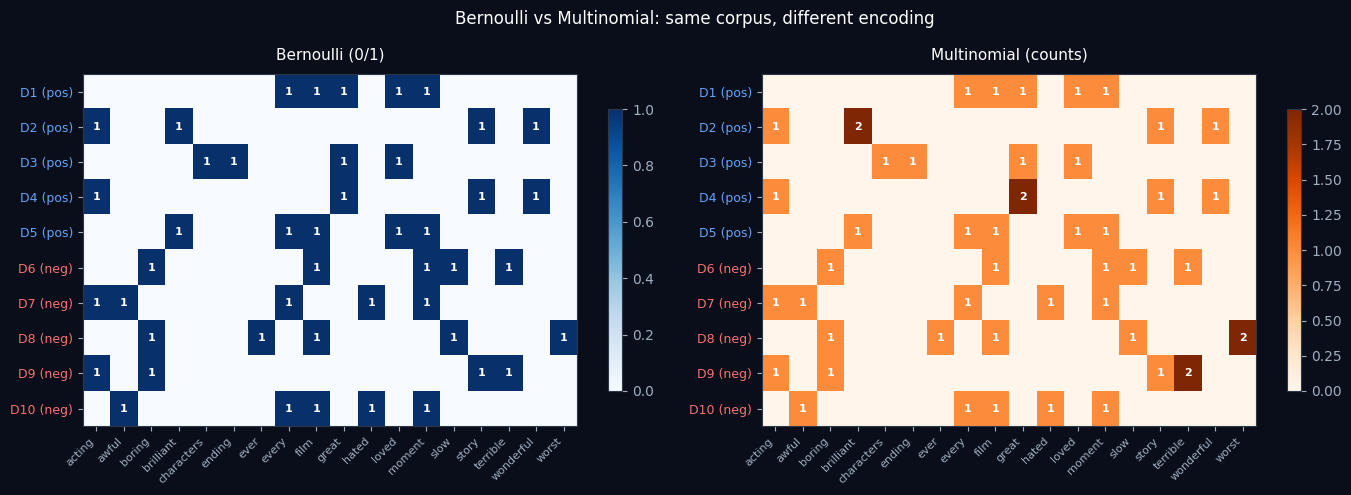

In [ ]:
# ── Visual: Bernoulli vs Multinomial as heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0e1a')

doc_labels = [f"D{i+1} ({l})" for i, (_, l) in enumerate(corpus)]

for ax_idx, (X_mat, title, cmap) in enumerate([
    (X_bern,  'Bernoulli (0/1)',      'Blues'),
    (X_multi, 'Multinomial (counts)', 'Oranges'),
]):
    ax = axes[ax_idx]
    ax.set_facecolor('#0d1117')
    im = ax.imshow(X_mat, aspect='auto', cmap=cmap,
                   vmin=0, vmax=max(1, X_mat.max()))

    for r in range(X_mat.shape[0]):
        for c in range(X_mat.shape[1]):
            val = X_mat[r, c]
            if val > 0:
                brightness = val / max(1, X_mat.max())
                txt_color = 'white' if brightness > 0.4 else '#1a1a1a'
                ax.text(c, r, str(val), ha='center', va='center',
                        fontsize=8, color=txt_color, fontweight='bold')

    ax.set_xticks(range(V))
    ax.set_xticklabels(list(vocab.keys()), rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(docs)))
    ax.set_yticklabels(doc_labels, fontsize=9)

    for tick, lbl in zip(ax.get_yticklabels(), labels):
        tick.set_color(BLUE if lbl == 'pos' else RED)

    ax.set_title(title, color='white', fontsize=11, pad=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Bernoulli vs Multinomial: same corpus, different encoding',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Bernoulli Naive Bayes from Scratch

### 2.1 The Model

Naive Bayes applies Bayes' theorem with the conditional independence assumption:

$$P(c \mid \mathbf{x}) \propto P(c) \prod_{t=1}^{|V|} P(x_t \mid c)$$

For Bernoulli NB, each word $w_t$ has a Bernoulli parameter $p_{t|c}$: the probability that $w_t$ **appears** in a class-$c$ document.
The likelihood of a document $\mathbf{x} \in \{0,1\}^{|V|}$ given class $c$ is:

$$P(\mathbf{x} \mid c) = \prod_{t=1}^{|V|} p_{t|c}^{x_t} (1 - p_{t|c})^{1 - x_t}$$

Note that **both present and absent words contribute**. This is the key structural difference from Multinomial NB.

**Training:** estimate $p_{t|c}$ by counting how many class-$c$ documents contain $w_t$:

$$\hat{p}_{t|c} = \frac{N_{tc}}{N_c}$$

where $N_{tc}$ = number of class-$c$ documents containing $w_t$, and $N_c$ = total class-$c$ documents.

In [ ]:
class BernoulliNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing parameter

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.log_prior_    = {}
        self.log_likelihood_ = {}  # log p(t|c) and log(1-p(t|c))

        N = len(y)
        for c in self.classes_:
            mask      = (y == c)
            N_c       = mask.sum()
            # Laplace-smoothed probability that word t appears in class c
            p_tc      = (X[mask].sum(axis=0) + self.alpha) / (N_c + 2 * self.alpha)
            self.log_prior_[c]      = np.log(N_c / N)
            self.log_likelihood_[c] = (np.log(p_tc), np.log(1 - p_tc))
        return self

    def predict_log_prob(self, x):
        scores = {}
        for c in self.classes_:
            log_p, log_1mp = self.log_likelihood_[c]
            # present words contribute log p, absent words contribute log(1-p)
            score = self.log_prior_[c] + (x * log_p + (1 - x) * log_1mp).sum()
            scores[c] = score
        return scores

    def predict(self, X):
        return [max(self.predict_log_prob(x), key=lambda k: self.predict_log_prob(x)[k])
                for x in X]

# ── Train on our toy corpus ──
y = np.array(labels)
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_bern, y)

print("Training complete.")
print(f"Classes: {bnb.classes_}")
print()

# Show learned word probabilities per class
df_probs = pd.DataFrame({
    f"p(t | pos)": np.exp(bnb.log_likelihood_['pos'][0]),
    f"p(t | neg)": np.exp(bnb.log_likelihood_['neg'][0]),
}, index=list(vocab.keys())).round(3)
print("Learned word probabilities:")
display(df_probs)

Training complete.
Classes: ['neg' 'pos']

Learned word probabilities:


,p(t | pos),p(t | neg)
acting,0.429,0.429
awful,0.143,0.429
boring,0.143,0.571
brilliant,0.429,0.143
characters,0.286,0.143
ending,0.286,0.143
ever,0.143,0.286
every,0.429,0.429
film,0.429,0.571
great,0.571,0.143


### 2.2 Classification: Log-space Scoring

We work in **log space** to avoid numerical underflow. Multiplying many small probabilities together drives the product to zero very quickly. Taking the log converts the product to a sum:

$$\log P(c \mid \mathbf{x}) \propto \log P(c) + \sum_{t=1}^{|V|} \left[ x_t \log p_{t|c} + (1-x_t) \log(1 - p_{t|c}) \right]$$

In [ ]:
# ── Classify a new review ──
test_reviews = [
    "loved film great",           # clearly pos
    "slow film",                  # clearly neg
    "great film slow ending",     # ambiguous
]

print("=" * 55)
for review in test_reviews:
    x_test = bernoulli_encode(review, vocab)
    scores = bnb.predict_log_prob(x_test)
    pred   = max(scores, key=scores.get)
    print(f"  Review : '{review}'")
    print(f"  log P(pos|x) = {scores['pos']:.3f}   log P(neg|x) = {scores['neg']:.3f}")
    print(f"  Prediction   : {pred}")
    print("-" * 55)

  Review : 'loved film great'
  log P(pos|x) = -7.769   log P(neg|x) = -11.823
  Prediction   : pos
-------------------------------------------------------
  Review : 'slow film'
  log P(pos|x) = -10.136   log P(neg|x) = -8.527
  Prediction   : neg
-------------------------------------------------------
  Review : 'great film slow ending'
  log P(pos|x) = -10.765   log P(neg|x) = -12.111
  Prediction   : pos
-------------------------------------------------------


### 2.3 Per-word Contribution

Every word in the vocabulary contributes to the score, not just the words in the document.
Words that are absent push the score in the opposite direction through the $(1 - p_{t|c})$ term.
This visualization shows how each word shifts the log-likelihood ratio toward pos or neg.

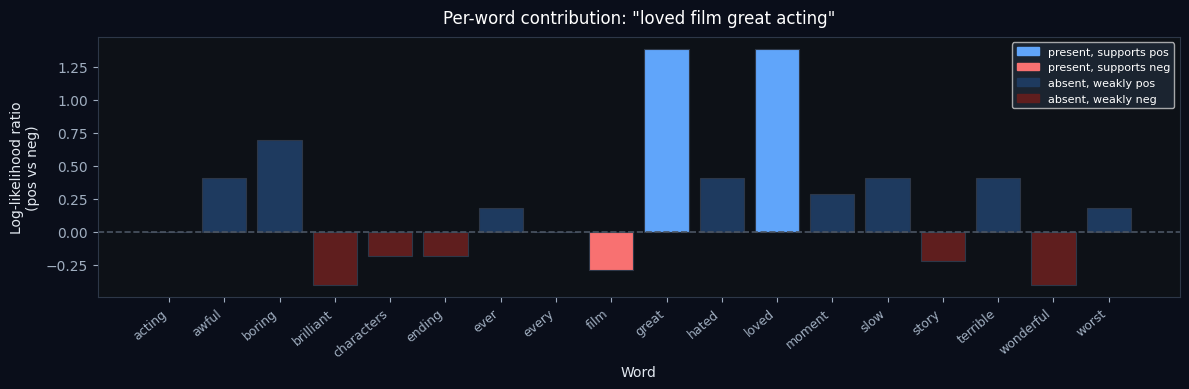

In [ ]:
def plot_word_contributions(review, bnb, vocab):
    x       = bernoulli_encode(review, vocab)
    log_p   = bnb.log_likelihood_['pos'][0]
    log_1mp = bnb.log_likelihood_['pos'][1]
    log_q   = bnb.log_likelihood_['neg'][0]
    log_1mq = bnb.log_likelihood_['neg'][1]

    # Log-likelihood ratio: positive means "supports pos"
    llr = (x * log_p + (1-x) * log_1mp) - (x * log_q + (1-x) * log_1mq)

    words   = list(vocab.keys())
    present = x.astype(bool)

    fig, ax = plt.subplots(figsize=(12, 4))
    fig.patch.set_facecolor('#0a0e1a')
    ax.set_facecolor('#0d1117')

    colors = []
    for i, (ratio, pres) in enumerate(zip(llr, present)):
        if ratio > 0:
            colors.append(BLUE if pres else '#1e3a5f')
        else:
            colors.append(RED  if pres else '#5f1e1e')

    bars = ax.bar(words, llr, color=colors, edgecolor='#2d3748', lw=0.8)
    ax.axhline(0, color='#4b5563', lw=1.2, linestyle='--')

    ax.set_xlabel('Word', color='#e2e8f0')
    ax.set_ylabel('Log-likelihood ratio\n(pos vs neg)', color='#e2e8f0')
    ax.set_title(f'Per-word contribution: "{review}"', color='white', pad=10)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=40, ha='right', fontsize=9)

    legend_patches = [
        mpatches.Patch(color=BLUE,    label='present, supports pos'),
        mpatches.Patch(color=RED,     label='present, supports neg'),
        mpatches.Patch(color='#1e3a5f', label='absent, weakly pos'),
        mpatches.Patch(color='#5f1e1e', label='absent, weakly neg'),
    ]
    ax.legend(handles=legend_patches, facecolor='#1f2937', labelcolor='white', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_word_contributions("loved film great acting", bnb, vocab)

## 3. Multinomial Naive Bayes from Scratch

### 3.1 The Model

Multinomial NB treats a document as a **bag of tokens**: we care about how many times each word appears, not just whether it appears.
The likelihood is:

$$P(\mathbf{x} \mid c) \propto \prod_{t=1}^{|V|} P(w_t \mid c)^{x_t}$$

(The multinomial coefficient $\frac{n_d!}{x_1! \cdots x_{|V|}!}$ is the same for all classes and cancels in the argmax comparison.)

**Training:** estimate $P(w_t \mid c)$ as the fraction of all tokens in class-$c$ documents that are $w_t$:

$$\hat{P}(w_t \mid c) = \frac{T_{ct}}{\sum_{t'} T_{ct'}}$$

where $T_{ct}$ = total count of word $w_t$ across all class-$c$ documents.

**Log-space scoring** (only present words matter, unlike Bernoulli):

$$\log P(c \mid \mathbf{x}) \propto \log P(c) + \sum_{t: x_t > 0} x_t \log P(w_t \mid c)$$

### 3.2 The Classic Example: China vs. Not China

This is the worked example. We build it entirely from scratch so every step is visible.

In [ ]:
# ── Training data ──
china_docs = [
    "Chinese Beijing Chinese",
    "Chinese Chinese Shanghai",
    "Chinese Macao",
]
notchina_docs = [
    "Tokyo Japan Chinese",
]

train_corpus = china_docs + notchina_docs
train_labels = ['China'] * 3 + ['notChina'] * 1

# Build vocabulary
china_vocab_set = set(w for d in train_corpus for w in d.split())
china_vocab     = sorted(china_vocab_set)
china_vidx      = {w: i for i, w in enumerate(china_vocab)}
V_china         = len(china_vocab)

print("Vocabulary:", china_vocab)
print(f"Classes: China ({len(china_docs)} docs), notChina ({len(notchina_docs)} docs)")

Vocabulary: ['Beijing', 'Chinese', 'Japan', 'Macao', 'Shanghai', 'Tokyo']
Classes: China (3 docs), notChina (1 docs)


In [ ]:
class MultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, docs, labels):
        self.classes_    = sorted(set(labels))
        self.vocab_      = sorted(set(w for d in docs for w in d.split()))
        self.word_idx_   = {w: i for i, w in enumerate(self.vocab_)}
        V                = len(self.vocab_)
        N                = len(labels)

        self.log_prior_   = {}
        self.log_cond_    = {}   # log P(w | c) for each class

        for c in self.classes_:
            c_docs   = [d for d, l in zip(docs, labels) if l == c]
            N_c      = len(c_docs)
            self.log_prior_[c] = np.log(N_c / N)

            # Count total tokens per word in class c
            counts = np.zeros(V)
            for d in c_docs:
                for w in d.split():
                    if w in self.word_idx_:
                        counts[self.word_idx_[w]] += 1

            # Laplace-smoothed MLE
            total = counts.sum() + self.alpha * V
            self.log_cond_[c] = np.log((counts + self.alpha) / total)
        return self

    def predict_log_prob(self, doc):
        words  = doc.split()
        scores = {}
        for c in self.classes_:
            score = self.log_prior_[c]
            for w in words:
                if w in self.word_idx_:
                    score += self.log_cond_[c][self.word_idx_[w]]
            scores[c] = score
        return scores

    def predict(self, docs):
        return [max(self.predict_log_prob(d), key=lambda k: self.predict_log_prob(d)[k])
                for d in docs]

mnb = MultinomialNB(alpha=1.0)
mnb.fit(train_corpus, train_labels)

print("Priors:")
for c in mnb.classes_:
    print(f"  P({c}) = {np.exp(mnb.log_prior_[c]):.4f}")

print()
print("Word likelihoods (Laplace smoothed, alpha=1):")
df_cond = pd.DataFrame({c: np.exp(mnb.log_cond_[c]) for c in mnb.classes_},
                         index=mnb.vocab_).round(4)
display(df_cond)

Priors:
  P(China) = 0.7500
  P(notChina) = 0.2500

Word likelihoods (Laplace smoothed, alpha=1):


,China,notChina
Beijing,0.1429,0.1111
Chinese,0.4286,0.2222
Japan,0.0714,0.2222
Macao,0.1429,0.1111
Shanghai,0.1429,0.1111
Tokyo,0.0714,0.2222


In [ ]:
# ── Classify the test document ──
test_doc = "Chinese Chinese Chinese Tokyo Japan"

scores = mnb.predict_log_prob(test_doc)
pred   = max(scores, key=scores.get)

print(f"Test document: '{test_doc}'")
print()
print("Log-score computation:")
for c in mnb.classes_:
    words = test_doc.split()
    parts = [f"log P({c}) = {mnb.log_prior_[c]:.4f}"]
    total = mnb.log_prior_[c]
    for w in words:
        if w in mnb.word_idx_:
            lp = mnb.log_cond_[c][mnb.word_idx_[w]]
            parts.append(f"log P({w}|{c}) = {lp:.4f}")
            total += lp
    print(f"  {c}: " + " + ".join(parts))
    print(f"  {c} total log-score = {total:.4f}")
    print()

print(f"Predicted class: {pred}")

Test document: 'Chinese Chinese Chinese Tokyo Japan'

Log-score computation:
  China: log P(China) = -0.2877 + log P(Chinese|China) = -0.8473 + log P(Chinese|China) = -0.8473 + log P(Chinese|China) = -0.8473 + log P(Tokyo|China) = -2.6391 + log P(Japan|China) = -2.6391
  China total log-score = -8.1077

  notChina: log P(notChina) = -1.3863 + log P(Chinese|notChina) = -1.5041 + log P(Chinese|notChina) = -1.5041 + log P(Chinese|notChina) = -1.5041 + log P(Tokyo|notChina) = -1.5041 + log P(Japan|notChina) = -1.5041
  notChina total log-score = -8.9067

Predicted class: China


## 4. Laplace Smoothing

### 4.1 The Zero-Probability Problem

Without smoothing, a word that **never appears** in training documents of class $c$ gets $\hat{P}(w_t \mid c) = 0$.
Because NB multiplies likelihoods together, a single zero kills the entire posterior for that class, no matter how strong the other evidence is.

In [ ]:
# ── Demonstrate the failure ──
mnb_unsmoothed = MultinomialNB(alpha=0.0)   # no smoothing
mnb_unsmoothed.fit(train_corpus, train_labels)

# "Macao" never appears in notChina training docs
# Check what happens when it appears in a test doc
test_fail = "Tokyo Tokyo Tokyo Tokyo Tokyo"

scores_bad = mnb_unsmoothed.predict_log_prob(test_fail)

print(f"Test document: '{test_fail}'")
print()
print("WITHOUT Laplace smoothing (alpha=0):")
for c, s in scores_bad.items():
    print(f"  log P({c} | x) = {s}")
print()
print("Note: -inf means P = 0, one zero word wipes out the entire class score.")

# Show which word is responsible
print()
print("Word likelihoods (no smoothing) for class 'notChina':")
for w in test_fail.split():
    if w in mnb_unsmoothed.word_idx_:
        lp = mnb_unsmoothed.log_cond_['notChina'][mnb_unsmoothed.word_idx_[w]]
        print(f"  P({w} | notChina) = {np.exp(lp):.4f}  (log = {lp:.4f})")

Test document: 'Tokyo Tokyo Tokyo Tokyo Macao Tokyo'

WITHOUT Laplace smoothing (alpha=0):
  log P(China | x) = -inf
  log P(notChina | x) = -inf

Note: -inf means P = 0, one zero word wipes out the entire class score.

Word likelihoods (no smoothing) for class 'notChina':
  P(Tokyo | notChina) = 0.3333  (log = -1.0986)
  P(Tokyo | notChina) = 0.3333  (log = -1.0986)
  P(Tokyo | notChina) = 0.3333  (log = -1.0986)
  P(Tokyo | notChina) = 0.3333  (log = -1.0986)
  P(Macao | notChina) = 0.0000  (log = -inf)
  P(Tokyo | notChina) = 0.3333  (log = -1.0986)


/tmp/ipykernel_742/1762499235.py:29: RuntimeWarning: divide by zero encountered in log
  self.log_cond_[c] = np.log((counts + self.alpha) / total)


### 4.2 The Fix: Add-$\alpha$ Smoothing

We add a pseudo-count $\alpha > 0$ to every word count before normalizing:

$$\hat{P}(w_t \mid c) = \frac{T_{ct} + \alpha}{\sum_{t'} T_{ct'} + \alpha |V|}$$

For $\alpha = 1$ this is called **Laplace smoothing** (add-one smoothing).

Two limiting behaviors are worth understanding:
- As $\alpha \to 0$: reverts to raw MLE, zero probabilities can occur.
- As $\alpha \to \infty$: the data counts are drowned out; every word gets equal probability $1/|V|$, and the prior dominates.

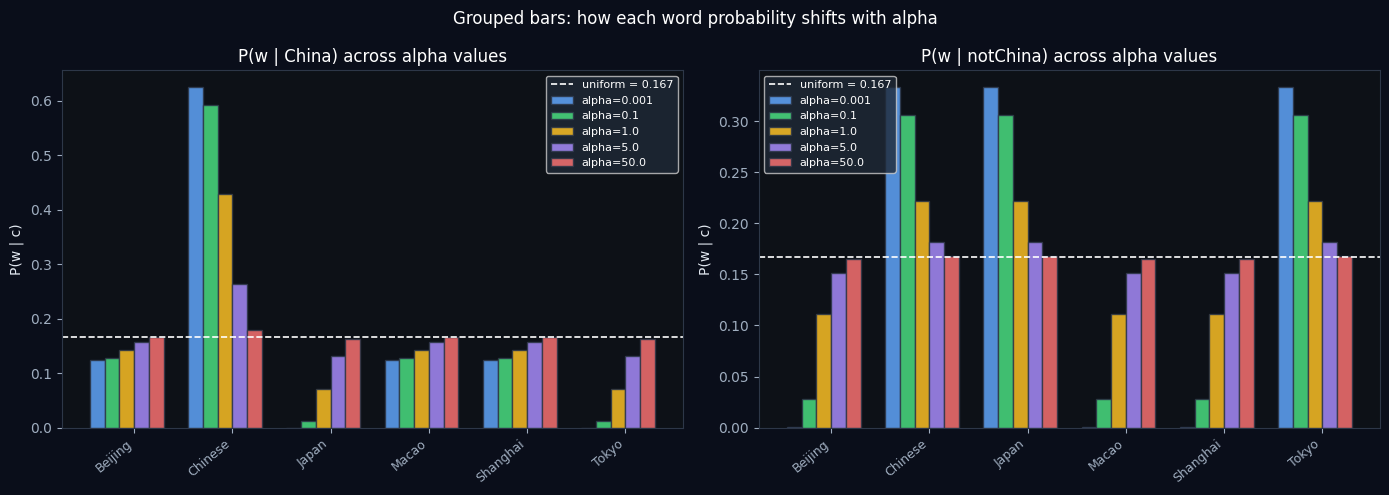

In [ ]:
def smooth_effect_grouped():
    alphas     = [0.001, 0.1, 1.0, 5.0, 50.0]
    alpha_colors = [BLUE, GREEN, AMBER, VIOLET, RED]
    classes    = ['China', 'notChina']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0a0e1a')

    words  = None
    n_words = None

    for ax_i, c in enumerate(classes):
        ax = axes[ax_i]
        ax.set_facecolor('#0d1117')

        all_probs = []
        for alpha in alphas:
            mnb_a = MultinomialNB(alpha=alpha)
            mnb_a.fit(train_corpus, train_labels)
            probs = np.exp(mnb_a.log_cond_[c])
            all_probs.append(probs)
            if words is None:
                words   = mnb_a.vocab_
                n_words = len(words)

        n_alpha = len(alphas)
        bw      = 0.15
        x_pos   = np.arange(n_words)

        for j, (alpha, probs, col) in enumerate(zip(alphas, all_probs, alpha_colors)):
            ax.bar(x_pos + j * bw, probs, bw, color=col, alpha=0.85,
                   label=f'alpha={alpha}', edgecolor='#2d3748')

        mnb_ref = MultinomialNB(alpha=1.0)
        mnb_ref.fit(train_corpus, train_labels)
        ax.axhline(1 / n_words, color='white', lw=1.2, linestyle='--',
                   label=f'uniform = {1/n_words:.3f}')

        ax.set_xticks(x_pos + bw * (n_alpha / 2))
        ax.set_xticklabels(words, rotation=40, ha='right', fontsize=9)
        ax.set_title(f'P(w | {c}) across alpha values', color='white')
        ax.set_ylabel('P(w | c)', color='#e2e8f0')
        ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=8)

    plt.suptitle('Grouped bars: how each word probability shifts with alpha',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.show()

smooth_effect_grouped()

## 5. TF-IDF

### 5.1 Why Raw Counts Mislead

Common words like "the", "a", "is" appear in nearly every document.
In a raw count vector they get large values, but they carry almost no discriminative information.
TF-IDF penalizes words that appear in many documents and rewards words that are rare across the corpus but frequent in a specific document.

$$\text{tf-idf}(t, d) = \underbrace{\left(1 + \log_{10} \text{tf}_{t,d}\right)}_{\text{log-scaled term frequency}} \cdot \underbrace{\log_{10} \frac{N}{\text{df}_t}}_{\text{inverse document frequency}}$$

where $\text{tf}_{t,d}$ = count of term $t$ in document $d$, $N$ = total documents, $\text{df}_t$ = number of documents containing $t$.

In [ ]:
# ── A corpus designed to show the "the" problem ──
tfidf_corpus = [
    "the the the match goal goal goal",        # sport
    "the the the the court trial trial",       # legal
    "the the the election election vote vote", # politics
    "the the the python code code import",     # tech
]
tfidf_labels = ["sport", "legal", "politics", "tech"]

# Build vocabulary
tfidf_words = sorted(set(w for d in tfidf_corpus for w in d.split()))
tfidf_vidx  = {w: i for i, w in enumerate(tfidf_words)}
W           = len(tfidf_words)
N_docs      = len(tfidf_corpus)

# Raw TF matrix
TF = np.array([[d.split().count(w) for w in tfidf_words] for d in tfidf_corpus])

df_tf = pd.DataFrame(TF, columns=tfidf_words, index=tfidf_labels)
print("Raw term-frequency matrix:")
display(df_tf)
print()
print("Note: 'the' has the highest counts but tells us nothing about the topic.")

Raw term-frequency matrix:


,code,court,election,goal,import,match,python,the,trial,vote
sport,0,0,0,3,0,1,0,3,0,0
legal,0,1,0,0,0,0,0,4,2,0
politics,0,0,2,0,0,0,0,3,0,2
tech,2,0,0,0,1,0,1,3,0,0



Note: 'the' has the highest counts but tells us nothing about the topic.


In [ ]:
def log_tf(tf_matrix):
    return np.where(tf_matrix > 0, 1 + np.log10(np.maximum(tf_matrix, 1)), 0)

def idf(tf_matrix):
    N   = tf_matrix.shape[0]
    df  = (tf_matrix > 0).sum(axis=0)
    return np.log10(N / np.maximum(df, 1))

def tfidf(tf_matrix):
    return log_tf(tf_matrix) * idf(tf_matrix)

TFIDF_mat = tfidf(TF)
IDF_vec   = idf(TF)

print("IDF values per word:")
df_idf = pd.DataFrame({'idf': IDF_vec.round(4)}, index=tfidf_words)
display(df_idf.T)
print()
print("'the' appears in all 4 documents  -->  idf = log10(4/4) = 0.  It is silenced.")

print()
df_tfidf = pd.DataFrame(TFIDF_mat.round(3), columns=tfidf_words, index=tfidf_labels)
print("TF-IDF matrix:")
display(df_tfidf)

IDF values per word:


,code,court,election,goal,import,match,python,the,trial,vote
idf,0.6021,0.6021,0.6021,0.6021,0.6021,0.6021,0.6021,0.0,0.6021,0.6021



'the' appears in all 4 documents  -->  idf = log10(4/4) = 0.  It is silenced.

TF-IDF matrix:


,code,court,election,goal,import,match,python,the,trial,vote
sport,0.000,0.000,0.000,0.889,0.000,0.602,0.000,0.0,0.000,0.000
legal,0.000,0.602,0.000,0.000,0.000,0.000,0.000,0.0,0.783,0.000
politics,0.000,0.000,0.783,0.000,0.000,0.000,0.000,0.0,0.000,0.783
tech,0.783,0.000,0.000,0.000,0.602,0.000,0.602,0.0,0.000,0.000


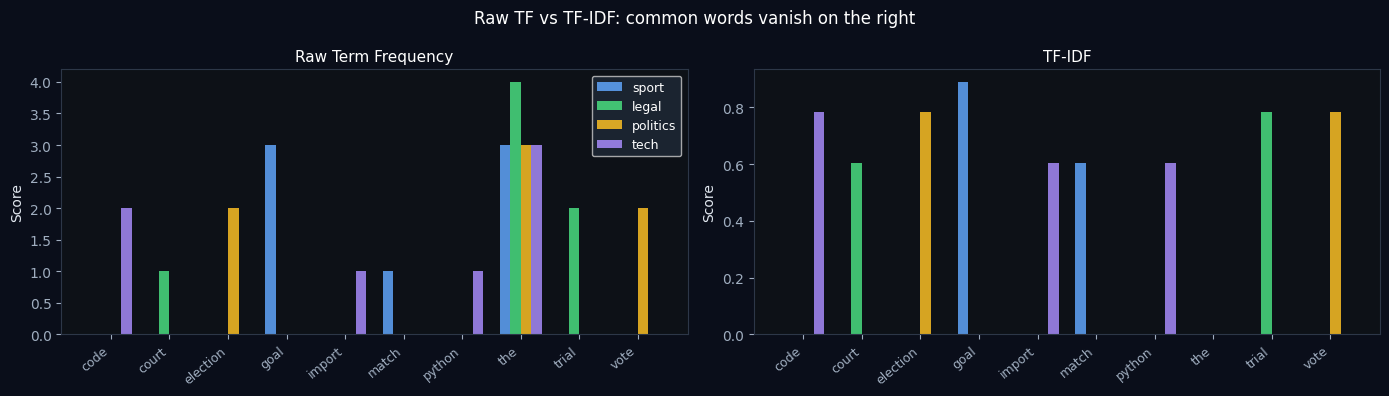

In [ ]:
# ── Visual: Raw TF vs TF-IDF ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0a0e1a')

doc_colors = [BLUE, GREEN, AMBER, VIOLET]

for ax_idx, (mat, title) in enumerate([(TF, 'Raw Term Frequency'),
                                        (TFIDF_mat, 'TF-IDF')]):
    ax = axes[ax_idx]
    ax.set_facecolor('#0d1117')
    x_pos = np.arange(W)
    bw    = 0.18
    for i, (row, col, lbl) in enumerate(zip(mat, doc_colors, tfidf_labels)):
        ax.bar(x_pos + i * bw, row, bw, color=col, alpha=0.85, label=lbl)
    ax.set_xticks(x_pos + bw * 1.5)
    ax.set_xticklabels(tfidf_words, rotation=40, ha='right', fontsize=9)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_ylabel('Score', color='#e2e8f0')
    if ax_idx == 0:
        ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=9)

plt.suptitle('Raw TF vs TF-IDF: common words vanish on the right',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

### 5.2 TF-IDF with Sklearn: Real Data

Let us verify on the 20 Newsgroups dataset that the representations actually differ in classification accuracy.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB as SKBernoulliNB, MultinomialNB as SKMultinomialNB
from sklearn.pipeline import Pipeline

cats = ["rec.sport.hockey", "sci.space", "talk.politics.guns"]
train_ng = fetch_20newsgroups(subset='train', categories=cats,
                               remove=('headers', 'footers', 'quotes'))
test_ng  = fetch_20newsgroups(subset='test',  categories=cats,
                               remove=('headers', 'footers', 'quotes'))

print(f"Train: {len(train_ng.data)} docs | Test: {len(test_ng.data)} docs")
print(f"Categories: {cats}")

Train: 1739 docs | Test: 1157 docs
Categories: ['rec.sport.hockey', 'sci.space', 'talk.politics.guns']


In [ ]:
pipelines = [
    ("Bernoulli NB",
     Pipeline([('vec', CountVectorizer(binary=True, min_df=2, stop_words='english')),
               ('clf', SKBernoulliNB())])),
    ("Multinomial NB",
     Pipeline([('vec', CountVectorizer(min_df=2, stop_words='english')),
               ('clf', SKMultinomialNB())])),
    ("TF-IDF + Multinomial NB",
     Pipeline([('vec', TfidfVectorizer(min_df=2, stop_words='english')),
               ('clf', SKMultinomialNB())])),
]

results = {}
for name, pipe in pipelines:
    pipe.fit(train_ng.data, train_ng.target)
    acc = pipe.score(test_ng.data, test_ng.target)
    results[name] = acc
    print(f"  {name:25s}  accuracy = {acc:.4f}")

  Bernoulli NB               accuracy = 0.8660
  Multinomial NB             accuracy = 0.9032
  TF-IDF + Multinomial NB    accuracy = 0.9144


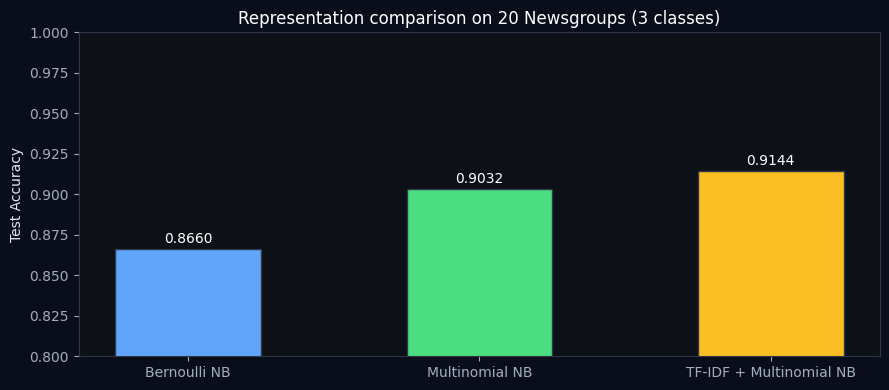

In [ ]:
# ── Bar chart of accuracies ──
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0a0e1a')
ax.set_facecolor('#0d1117')

names  = list(results.keys())
accs   = list(results.values())
colors = [BLUE, GREEN, AMBER]

bars = ax.bar(range(len(names)), accs, color=colors, width=0.5, edgecolor='#2d3748')
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Test Accuracy', color='#e2e8f0')
ax.set_title('Representation comparison on 20 Newsgroups (3 classes)', color='white')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=10)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.002,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.show()

## 6. Text Preprocessing Pipeline

Before vectorizing, we clean the raw text. Each step removes noise that would otherwise inflate the vocabulary or create spurious distinctions.

The standard pipeline:

1. **Lowercasing** -- "The" and "the" are the same word.  
2. **Tokenization and punctuation removal** -- split into words, strip non-alphabetic characters.  
3. **Stop-word removal** -- drop high-frequency words with little discriminative value ("the", "is", "a", ...).  
4. **Stemming or lemmatization** -- reduce inflected forms to a common base ("running" to "run").

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

raw = "The Leaves are Falling faster than the wind!"
print(f"Raw: '{raw}'")
print()

# Step 1: Lowercase
step1 = raw.lower()
print(f"Step 1 (lowercase)      : '{step1}'")

# Step 2: Tokenize + strip punctuation
step2 = re.sub(r'[^a-z\s]', '', step1).split()
print(f"Step 2 (tokenize)       : {step2}")

# Step 3: Stop-word removal
stop_en = set(stopwords.words('english'))
step3   = [w for w in step2 if w not in stop_en]
print(f"Step 3 (stop-words)     : {step3}")

# Step 4a: Porter stemming
stemmer = PorterStemmer()
step4a  = [stemmer.stem(w) for w in step3]
print(f"Step 4a (Porter stem)   : {step4a}")

# Step 4b: WordNet lemmatization
lemmatizer = WordNetLemmatizer()
step4b     = [lemmatizer.lemmatize(w) for w in step3]
print(f"Step 4b (lemmatize)     : {step4b}")

Raw: 'The Leaves are Falling faster than the wind!'

Step 1 (lowercase)      : 'the leaves are falling faster than the wind!'
Step 2 (tokenize)       : ['the', 'leaves', 'are', 'falling', 'faster', 'than', 'the', 'wind']
Step 3 (stop-words)     : ['leaves', 'falling', 'faster', 'wind']
Step 4a (Porter stem)   : ['leav', 'fall', 'faster', 'wind']
Step 4b (lemmatize)     : ['leaf', 'falling', 'faster', 'wind']


**Stemming vs Lemmatization:**

Stemming (Porter) aggressively strips suffixes with simple heuristic rules. It is fast but can produce non-words ("leav", "falli").
Lemmatization uses a vocabulary and morphological analysis to return valid dictionary forms ("leaf", "fall").
Lemmatization maps "better" to "good"; stemming does not. Stemming is faster; lemmatization is more linguistically correct.

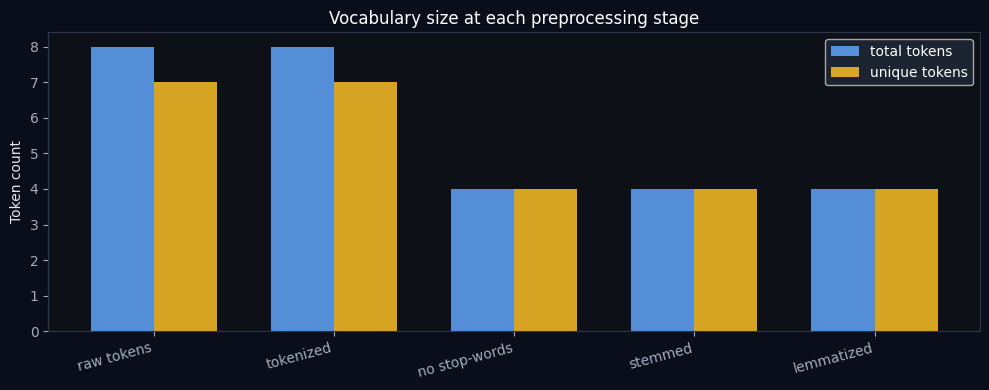

In [ ]:
# ── Visual: vocabulary size before and after each step ──
stages = {
    'raw tokens':    raw.lower().split(),
    'tokenized':     step2,
    'no stop-words': step3,
    'stemmed':       step4a,
    'lemmatized':    step4b,
}

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0a0e1a')
ax.set_facecolor('#0d1117')

stage_names = list(stages.keys())
tok_counts  = [len(tokens) for tokens in stages.values()]
uniq_counts = [len(set(tokens)) for tokens in stages.values()]

x = np.arange(len(stage_names))
w = 0.35
ax.bar(x - w/2, tok_counts,  w, color=BLUE,  label='total tokens',  alpha=0.85)
ax.bar(x + w/2, uniq_counts, w, color=AMBER, label='unique tokens', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(stage_names, rotation=15, ha='right')
ax.set_ylabel('Token count', color='#e2e8f0')
ax.set_title('Vocabulary size at each preprocessing stage', color='white')
ax.legend(facecolor='#1f2937', labelcolor='white')

plt.tight_layout()
plt.show()

## 7. What Did the Model Learn? Inspecting Top Features

After fitting a NB classifier, `feature_log_prob_` gives $\log P(w_t \mid c)$ for every word and class.
The words with the **highest** log probability for a class are the words the model considers most strongly associated with that class.
This is one of the most useful diagnostic tools for text classifiers: you can immediately see whether the model learned something sensible or whether it latched onto noise.

In [ ]:
# ── Fit on 5 newsgroups categories for a richer picture ──
cats5 = ["rec.sport.hockey", "sci.space", "talk.politics.guns",
         "comp.graphics", "rec.autos"]

train5 = fetch_20newsgroups(subset='train', categories=cats5,
                             remove=('headers', 'footers', 'quotes'))

vec5 = TfidfVectorizer(min_df=5, max_df=0.9, stop_words='english', max_features=10000)
clf5 = SKMultinomialNB()
X5   = vec5.fit_transform(train5.data)
clf5.fit(X5, train5.target)

print(f"Trained on {X5.shape[0]} documents, vocabulary = {X5.shape[1]} words")

Trained on 2917 documents, vocabulary = 6800 words


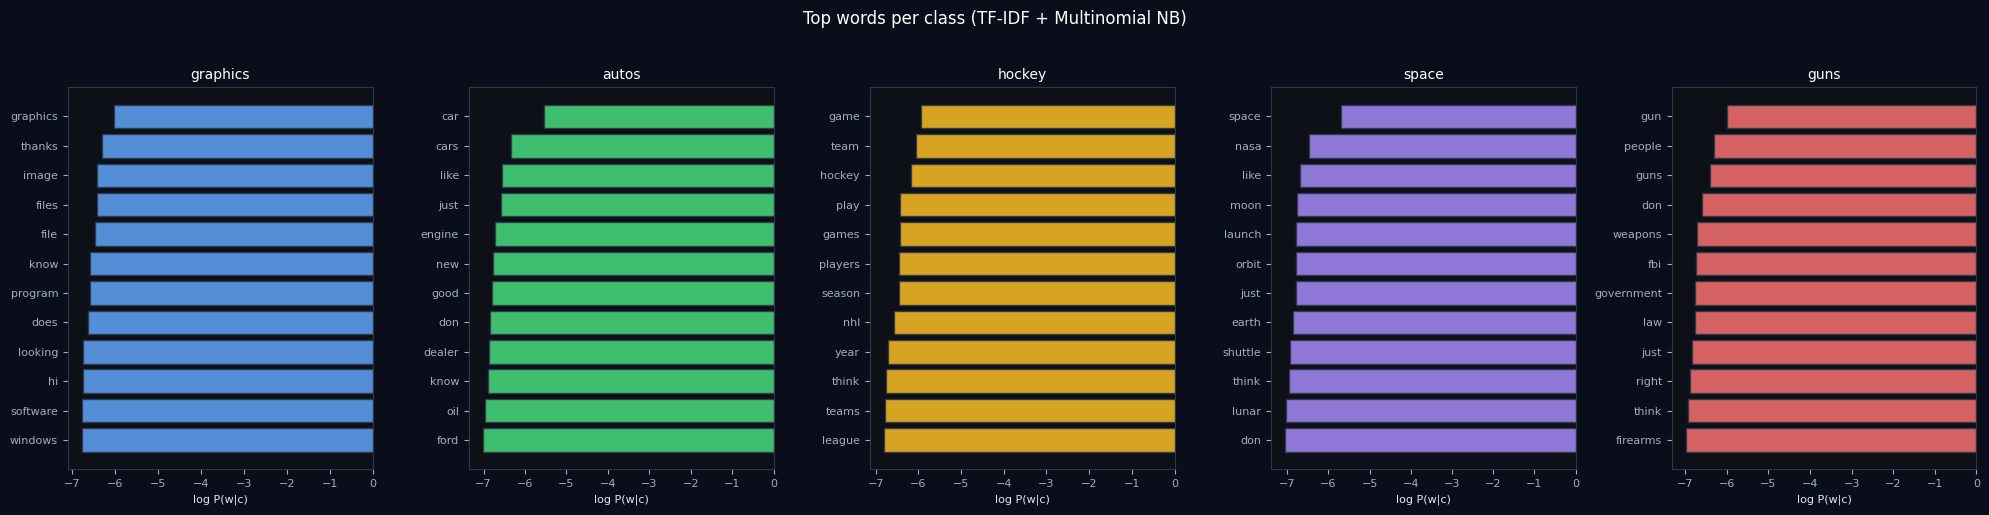

In [ ]:
def plot_top_words(clf, vectorizer, class_names, n=12):
    feature_names = np.array(vectorizer.get_feature_names_out())
    n_classes     = len(class_names)
    fig, axes     = plt.subplots(1, n_classes, figsize=(4 * n_classes, 5))
    fig.patch.set_facecolor('#0a0e1a')
    plot_colors = [BLUE, GREEN, AMBER, VIOLET, RED]

    for i, (ax, cls, col) in enumerate(zip(axes, class_names, plot_colors)):
        ax.set_facecolor('#0d1117')
        log_probs = clf.feature_log_prob_[i]
        top_idx   = log_probs.argsort()[-n:][::-1]
        top_words = feature_names[top_idx]
        top_probs = log_probs[top_idx]

        ax.barh(top_words, top_probs, color=col, alpha=0.85, edgecolor='#2d3748')
        ax.set_title(cls.split('.')[-1], color='white', fontsize=10)
        ax.tick_params(colors='#a0aec0', labelsize=8)
        ax.set_xlabel('log P(w|c)', color='#e2e8f0', fontsize=8)
        ax.invert_yaxis()

    plt.suptitle('Top words per class (TF-IDF + Multinomial NB)',
                 color='white', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

plot_top_words(clf5, vec5, [train5.target_names[i] for i in clf5.classes_], n=12)

The top words are interpretable: "puck", "nhl", "hockey" for the hockey category; "launch", "orbit", "nasa" for space.
This is a strong sanity check. If the top words made no sense, it would indicate a data problem (label noise, data leakage) or a preprocessing issue.

## Summary

**From text to vectors**  
A vocabulary $V$ maps each document to a fixed-length feature vector. Bernoulli uses binary presence; Multinomial uses token counts. The choice of representation affects which probabilistic model is appropriate.

**Bernoulli NB**  
Each word has a Bernoulli parameter $\hat{p}_{t|c} = N_{tc} / N_c$. At inference, every word in $V$ contributes to the log-score, including absent words through the $(1 - p_{t|c})$ term.

**Multinomial NB**  
Likelihood is proportional to $\prod_t P(w_t \mid c)^{x_t}$. Only words present in the test document contribute. The multinomial coefficient cancels and is never computed.

**Laplace smoothing**  
Add $\alpha > 0$ to every word count. Without it, a single unseen word zeroes out an entire class posterior. As $\alpha \to \infty$ the prior dominates and data evidence is washed out.

**TF-IDF**  
$\text{tf-idf}(t,d) = (1 + \log_{10} \text{tf}_{t,d}) \cdot \log_{10}(N / \text{df}_t)$. Words appearing in every document get IDF = 0 and are silenced. Rare but locally frequent words are up-weighted. This consistently outperforms raw counts.

**Preprocessing**  
Lowercasing, tokenization, stop-word removal, and stemming/lemmatization reduce vocabulary size and noise. The pipeline matters more than the classifier choice for most text tasks.

**Inspecting learned parameters**  
`feature_log_prob_` reveals what the model learned. Interpretable top words are a necessary (not sufficient) sanity check.